In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from concurrent.futures import ThreadPoolExecutor
from datetime import date

import cma
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import kge, mkge, nse, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_curve_number,
    jablje_groundwater,
    jablje_initial_cond,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_readily_evaporable_water,
    jablje_soil_layers,
)
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
K_FOLDS = 5
N_REPEATS = 10
MAX_WORKERS = os.cpu_count()

ALL_YEARS = [y for y in range(1993, 2024) if y != 2017]
print(f"Total years: {len(ALL_YEARS)}  ({ALL_YEARS[0]}–{ALL_YEARS[-1]}, excluding 2017)")
print(f"Total folds to run: {K_FOLDS * N_REPEATS}")

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}
print(f"Observed grain years: {sorted(observed_grain['year'].tolist())}")

Total years: 30  (1993–2023, excluding 2017)
Total folds to run: 50
Observed grain years: [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023]


In [4]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"cmaes_jablje_kfold_grain_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

Worker directories ready: 28


In [5]:
param_names = [
    "harvest_index",
    #"gdd_emergence",
    #"gdd_max_rooting",
    #"gdd_senescence",
    #"gdd_maturity",
    "gdd_flowering",
    "gdd_flowering_length",
    "gdd_hi_start",
    #"max_canopy_cover",
    #"cgc_gdd",
    #"cdc_gdd",
    #"ksat",
    #"min_rooting_depth",
    #"max_rooting_depth",
    "p_upper_senescence",
    "p_upper_stomata"
]

bounds = [
    (0.46, 0.6),    # harvest_index
    #(5, 40),        # gdd_emergence
    #(700, 1000),    # gdd_max_rooting
    #(700, 1000),    # gdd_senescence
    #(900, 1200),    # gdd_maturity
    (480,  530),    # gdd_flowering
    (130,  170),    # gdd_flowering_length
    (300, 500),     # gdd_hi_start
    #(0.85, 0.97),   # max_canopy_cover
    #(0.005, 0.03),  # cgc_gdd
    #(0.005, 0.02),  # cdc_gdd
    #(5, 1000),      # ksat
    #(0.05, 0.4),    # min_rooting_depth
    #(0.5, 2.5),     # max_rooting_depth
    (0.4, 0.8),     # p_upper_senescence
    (0.4, 0.8),     # p_upper_stomata
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

def to_unit(x):
    return (np.asarray(x) - lower) / (upper - lower)

def from_unit(x_norm):
    return lower + np.asarray(x_norm) * (upper - lower)

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")

Parameters: ['harvest_index', 'gdd_flowering', 'gdd_flowering_length', 'gdd_hi_start', 'p_upper_senescence', 'p_upper_stomata']
x0:         [  0.53 505.   150.   400.     0.6    0.6 ]


In [6]:
years_array = np.array(ALL_YEARS)

grain_series = observed_grain.set_index("year").loc[ALL_YEARS, "yield"]
grain_bins = pd.qcut(grain_series, q=K_FOLDS, labels=False).values

print("Grain quantile bins per year:")
for y, b, bio in zip(ALL_YEARS, grain_bins, grain_series):
    print(f"  {y}: {bio:.2f} t/ha → bin {b}")

kf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=N_REPEATS, random_state=42)

folds = []
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(years_array, grain_bins)):
    repeat  = fold_idx // K_FOLDS + 1
    split   = fold_idx  % K_FOLDS + 1
    train_years = years_array[train_idx].tolist()
    test_years  = years_array[test_idx].tolist()
    folds.append({"train": train_years, "test": test_years, "repeat": repeat, "split": split})

print(f"Total folds: {len(folds)}  ({N_REPEATS} repeats × {K_FOLDS} splits)")

Grain quantile bins per year:
  1993: 7.83 t/ha → bin 1
  1994: 10.42 t/ha → bin 3
  1995: 12.01 t/ha → bin 4
  1996: 8.27 t/ha → bin 1
  1997: 10.37 t/ha → bin 3
  1998: 8.89 t/ha → bin 1
  1999: 9.76 t/ha → bin 2
  2000: 10.13 t/ha → bin 2
  2001: 6.79 t/ha → bin 0
  2002: 12.08 t/ha → bin 4
  2003: 7.53 t/ha → bin 0
  2004: 6.11 t/ha → bin 0
  2005: 11.08 t/ha → bin 3
  2006: 7.82 t/ha → bin 1
  2007: 10.28 t/ha → bin 3
  2008: 9.15 t/ha → bin 2
  2009: 5.13 t/ha → bin 0
  2010: 7.48 t/ha → bin 0
  2011: 9.52 t/ha → bin 2
  2012: 10.64 t/ha → bin 3
  2013: 7.80 t/ha → bin 1
  2014: 10.29 t/ha → bin 3
  2015: 10.14 t/ha → bin 2
  2016: 9.37 t/ha → bin 2
  2018: 8.53 t/ha → bin 1
  2019: 12.00 t/ha → bin 4
  2020: 13.51 t/ha → bin 4
  2021: 11.08 t/ha → bin 4
  2022: 5.78 t/ha → bin 0
  2023: 12.65 t/ha → bin 4
Total folds: 50  (10 repeats × 5 splits)


In [7]:
def make_simulation_periods(years):
    return [
        {
            "start_date": date(y, 1, 1),
            "end_date":   date(y, 12, 31),
            "planting_date": date(y, 5, 3),
            "is_seeding_year": True,
        }
        for y in years
    ]


def evaluate_params(param_values, sim_periods):
    """Run one candidate on the given simulation periods and return grain metrics."""
    working_dir = dir_queue.get()
    try:
        crop_params = copy.deepcopy(jablje_maize_params)
        current_ksat = None

        for name, val in zip(param_names, param_values):
            if name == "ksat":
                current_ksat = float(val)
            else:
                crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="cma-es-kfold",
            params=crop_params,
        )

        if current_ksat is not None:
            modified_layers = copy.deepcopy(jablje_soil_layers)
            for layer in modified_layers:
                layer.ksat = current_ksat
            current_soil = Soil(
                name=f"{LOCATION} soil",
                description=f"{LOCATION} loamy sand soil",
                soil_layers=modified_layers,
                curve_number=jablje_curve_number,
                readily_evaporable_water=jablje_readily_evaporable_water,
            )
        else:
            current_soil = soil

        simulation = AquaCrop(
            simulation_periods=sim_periods,
            crop=crop,
            soil=current_soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_result = {"grain_rmse": np.nan, "grain_nse": np.nan, "grain_kge": np.nan, "grain_mkge": np.nan}

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_result

        seasonal = results["season"][["Year1", "Y(dry)"]].rename(
            columns={"Year1": "year", "Y(dry)": "grain_modeled"}
        )
        merged = observed_grain.merge(seasonal, on="year")
        if merged.empty:
            return nan_result

        y_obs = merged["yield"].values
        y_mod = merged["grain_modeled"].values
        return {
            "grain_rmse": root_mean_squared_error(y_obs, y_mod),
            "grain_nse":  nse(y_mod, y_obs),
            "grain_kge":  kge(y_mod, y_obs),
            "grain_mkge": mkge(y_mod, y_obs),
        }
    finally:
        dir_queue.put(working_dir)

In [8]:
SIGMA0 = 0.3
default_popsize = 4 + int(3 * np.log(len(param_names)))
POPSIZE = max(MAX_WORKERS, default_popsize)

x0_norm = to_unit(x0)  # all 0.5 — optimizer works in [0, 1]^n

CMAES_OPTIONS = {
    "bounds": [[0.0] * len(param_names), [1.0] * len(param_names)],
    "popsize": POPSIZE,
    "maxiter": 40, # based on loss function convergence run for one fold
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 43,
    "verbose": -9,   # suppress per-iteration output; fold progress printed manually
}

print(f"Cores: {MAX_WORKERS}  |  popsize: {POPSIZE}")

Cores: 28  |  popsize: 28


In [9]:
def run_fold(fold_idx, train_years, test_years, repeat, split):
    """Fit CMA-ES on train_years, evaluate on train and test. Returns a result dict."""
    train_periods = make_simulation_periods(train_years)
    test_periods  = make_simulation_periods(test_years)

    def objective(x_norm):
        r = evaluate_params(from_unit(x_norm), train_periods)
        return -r["grain_mkge"] if np.isfinite(r["grain_mkge"]) else 1e6

    def parallel_evaluate(solutions):
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            return list(executor.map(objective, solutions))

    es = cma.CMAEvolutionStrategy(x0_norm, SIGMA0, CMAES_OPTIONS)
    convergence = []
    while not es.stop():
        solutions = es.ask()
        fitnesses = parallel_evaluate(solutions)
        penalty = max((f for f in fitnesses if np.isfinite(f)), default=1e6) * 10
        fitnesses = [penalty if not np.isfinite(f) else f for f in fitnesses]
        es.tell(solutions, fitnesses)
        convergence.append((es.result.iterations, es.result.fbest))

    xbest = from_unit(es.result.xbest)  # convert back to actual parameter values

    train_metrics = evaluate_params(xbest, train_periods)
    test_metrics  = evaluate_params(xbest, test_periods)

    total = K_FOLDS * N_REPEATS
    print(
        f"[{fold_idx+1}/{total}] repeat={repeat} split={split} — "
        f"train mkge={train_metrics['grain_mkge']:.4f}  "
        f"test mkge={test_metrics['grain_mkge']:.4f}  "
        f"(iters={es.result.iterations})"
    )

    return {
        "fold":        fold_idx + 1,
        "repeat":      repeat,
        "split":       split,
        "train_years": train_years,
        "test_years":  test_years,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}":  v for k, v in test_metrics.items()},
        **{f"best_{n}":  v for n, v in zip(param_names, xbest)},
        "iterations":  es.result.iterations,
        "evaluations": es.result.evaluations,
        "convergence": convergence,
    }

In [10]:
print(f"Running {N_REPEATS}×{K_FOLDS}-fold repeated stratified CV (objective: grain mKGE) …")
fold_results = []
for fold_idx, fold in enumerate(folds):
    print(f"Fold {fold_idx+1}/{len(folds)}", flush=True)
    result = run_fold(fold_idx, fold["train"], fold["test"], fold["repeat"], fold["split"])
    fold_results.append(result)

print("\nAll folds complete.")

Running 10×5-fold repeated stratified CV (objective: grain mKGE) …
Fold 1/50
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [11]:
import pickle

pickle.dump(fold_results, open(config.RESULTS_DIR / "cmaes_jablje_kfold_grain.pkl", "wb"))
print(f"Saved {len(fold_results)} fold results to {config.RESULTS_DIR / 'cmaes_jablje_kfold_grain.pkl'}")

In [12]:
results_df = pd.DataFrame(fold_results)

metric_cols = ["train_grain_mkge", "train_grain_nse", "train_grain_rmse",
               "test_grain_mkge",  "test_grain_nse",  "test_grain_rmse"]

# Per-repeat summary: mean metric across the 5 splits within each repeat
repeat_summary = results_df.groupby("repeat")[metric_cols].mean().round(4)
print(f"Per-repeat mean metrics ({K_FOLDS} splits averaged):")
display(repeat_summary)

means = results_df[metric_cols].mean()
stds  = results_df[metric_cols].std()
print(f"\nOverall mean ± std across all {len(results_df)} folds ({N_REPEATS} repeats × {K_FOLDS} splits):")
for col in metric_cols:
    print(f"  {col}: {means[col]:.4f} ± {stds[col]:.4f}")

,train_grain_mkge,train_grain_nse,train_grain_rmse,test_grain_mkge,test_grain_nse,test_grain_rmse
repeat,,,,,,
1,0.5634,0.1529,1.8754,0.2559,-0.1241,1.9854
2,0.5675,0.1700,1.8610,0.3332,0.0151,1.9253
3,0.5711,0.1766,1.8538,0.2288,-0.0447,2.0061
4,0.5662,0.1044,1.9337,0.4068,-0.0642,2.0339
5,0.5745,0.1487,1.8822,0.3209,-0.1004,2.0221
6,0.5728,0.1456,1.8903,0.4745,-0.0765,2.0072
7,0.5665,0.1419,1.8904,0.2375,-0.3226,2.1376
8,0.5615,0.1268,1.9076,0.3396,-0.0400,1.9490
9,0.5671,0.1801,1.8450,0.3374,-0.1612,2.1038


C:\Users\rokku\AppData\Local\Temp\ipykernel_19120\2040617239.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


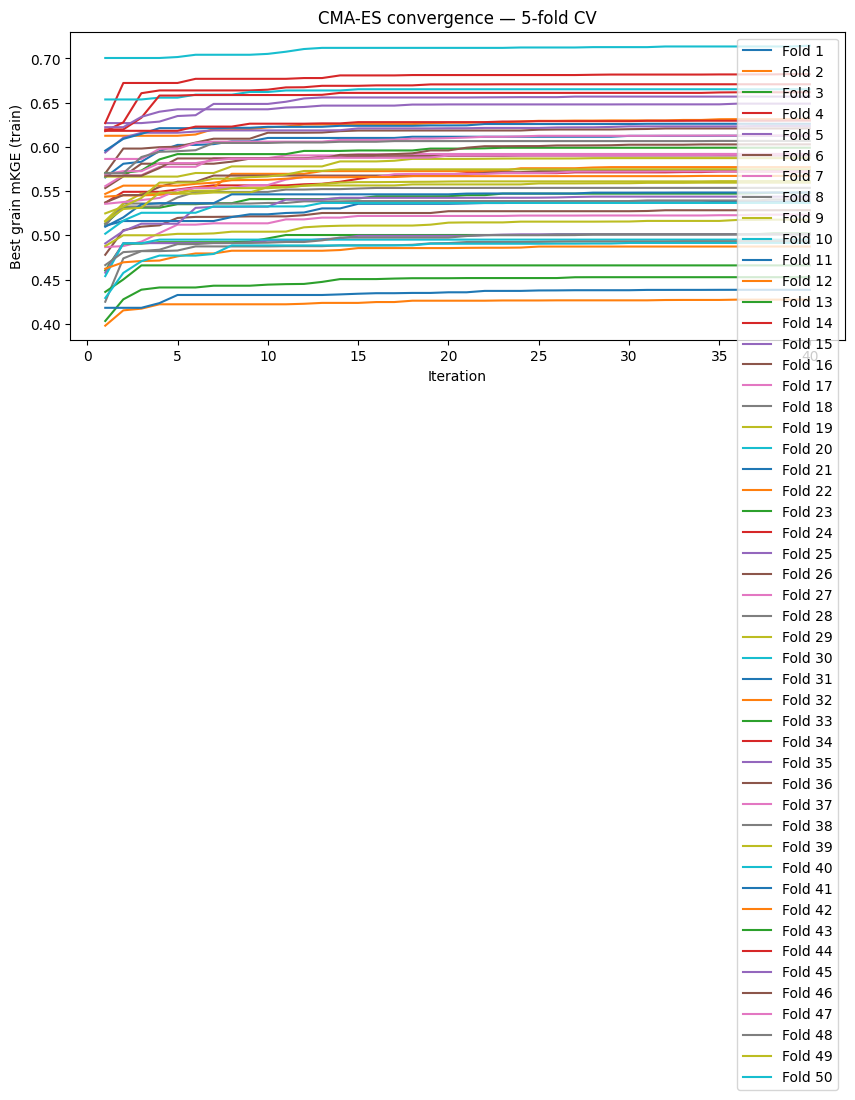

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

for result in fold_results:
    iters, fbest = zip(*result["convergence"])
    # fbest is -grain_mkge (CMA-ES minimises), convert back to mKGE
    mkge_best = [-f for f in fbest]
    ax.plot(iters, mkge_best, label=f"Fold {result['fold']}")

ax.set_xlabel("Iteration")
ax.set_ylabel("Best grain mKGE (train)")
ax.set_title(f"CMA-ES convergence — {K_FOLDS}-fold CV")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
best_param_cols = [f"best_{n}" for n in param_names]
print("Best parameters per fold:")
display(results_df[best_param_cols].round(6))

print("\nMean best parameters:")
for col in best_param_cols:
    name = col.replace("best_", "")
    print(f"  {name}: {results_df[col].mean():.6f} ± {results_df[col].std():.6f}")

,best_harvest_index,best_gdd_flowering,best_gdd_flowering_length,best_gdd_hi_start,best_p_upper_senescence,best_p_upper_stomata
0,0.534759,480.869150,146.758333,311.159342,0.799599,0.799072
1,0.547579,481.250109,164.836248,302.354739,0.570015,0.536885
2,0.531163,481.066905,165.611488,301.294437,0.799935,0.800000
3,0.540548,480.999824,164.728299,468.805622,0.569365,0.402080
4,0.543422,493.799126,167.582517,300.841408,0.567717,0.400771
5,0.553738,480.570573,134.968632,303.872985,0.569379,0.404470
6,0.518206,492.372950,168.341298,305.615523,0.796642,0.799706
7,0.529715,481.688286,169.991655,302.066409,0.568084,0.400041
8,0.541810,480.594761,153.855749,307.438211,0.567779,0.468628
9,0.540292,491.315861,131.093301,458.560437,0.799016,0.772416


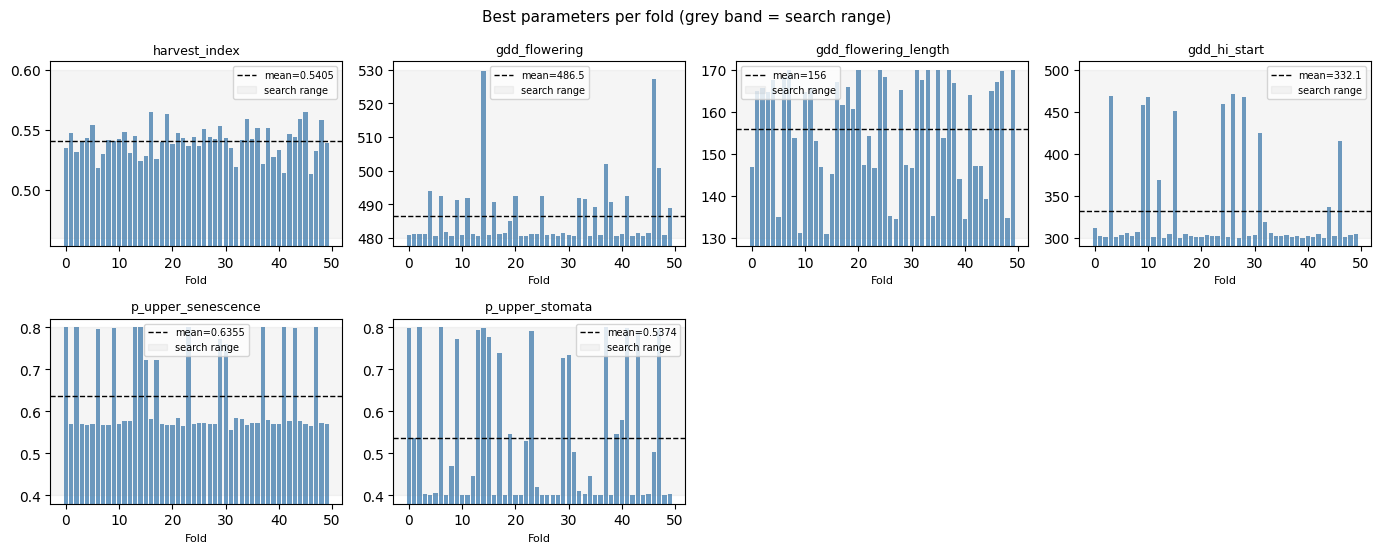

In [15]:
n_params = len(param_names)
ncols = 4
nrows = (n_params + ncols - 1) // ncols

bounds_dict = dict(zip(param_names, bounds))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8))
axes = axes.flatten()

for i, name in enumerate(param_names):
    col = f"best_{name}"
    vals = results_df[col]
    lo, hi = bounds_dict[name]

    ax = axes[i]
    ax.bar(results_df.index, vals, color="steelblue", alpha=0.8)
    ax.axhline(vals.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={vals.mean():.4g}")
    ax.axhspan(lo, hi, color="grey", alpha=0.08, label="search range")
    ax.set_ylim(lo - 0.05 * (hi - lo), hi + 0.05 * (hi - lo))
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Fold", fontsize=8)
    ax.legend(fontsize=7)

for j in range(n_params, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Best parameters per fold (grey band = search range)", fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
best_param_cols = [f"best_{n}" for n in param_names]
param_stats = pd.DataFrame({
    "lower_bound":  [lo for lo, hi in bounds],
    "upper_bound":  [hi for lo, hi in bounds],
    "mean":   results_df[best_param_cols].mean().values,
    "median": results_df[best_param_cols].median().values,
    "std":    results_df[best_param_cols].std().values,
}, index=param_names)
display(param_stats.round(6))

,lower_bound,upper_bound,mean,median,std
harvest_index,0.46,0.6,0.540474,0.542029,0.012604
gdd_flowering,480.00,530.0,486.478505,481.252489,10.404874
gdd_flowering_length,130.00,170.0,155.996878,162.745905,13.265048
gdd_hi_start,300.00,500.0,332.057337,302.719166,59.087988
p_upper_senescence,0.40,0.8,0.635531,0.572865,0.099814
p_upper_stomata,0.40,0.8,0.537381,0.433343,0.168000


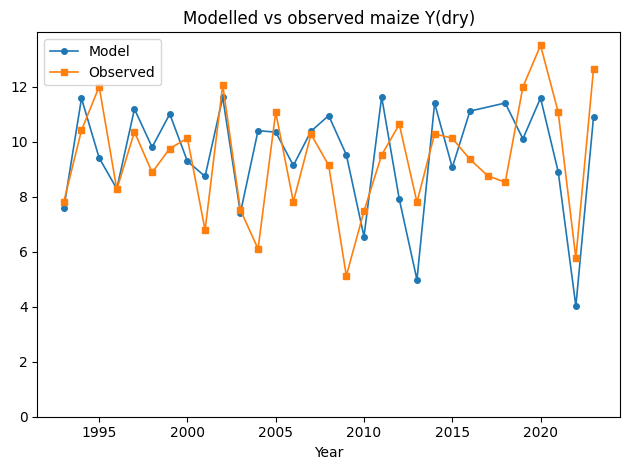

In [17]:
mean_params = param_stats["mean"].values

crop_params_avg = copy.deepcopy(jablje_maize_params)
avg_ksat = None
for name, val in zip(param_names, mean_params):
    if name == "ksat":
        avg_ksat = float(val)
    else:
        crop_params_avg[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

if avg_ksat is not None:
    avg_layers = copy.deepcopy(jablje_soil_layers)
    for layer in avg_layers:
        layer.ksat = avg_ksat
    avg_soil = Soil(
        name=f"{LOCATION} soil",
        description="avg-params",
        soil_layers=avg_layers,
        curve_number=jablje_curve_number,
        readily_evaporable_water=jablje_readily_evaporable_water,
    )
else:
    avg_soil = soil

avg_dir = config.RAMDISK_DIR / "cmaes_jablje_kfold_grain_avg"
avg_dir.mkdir(parents=True, exist_ok=True)

all_periods = make_simulation_periods(ALL_YEARS)
sim_avg = AquaCrop(
    simulation_periods=all_periods,
    crop=Crop(name=f"{LOCATION} maize", description="kfold-avg", params=crop_params_avg),
    soil=avg_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather,
    working_dir=avg_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)
with contextlib.redirect_stdout(io.StringIO()):
    seasonal_avg = sim_avg.run()["season"]

plot_yield_timeseries_comparison(seasonal_avg, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

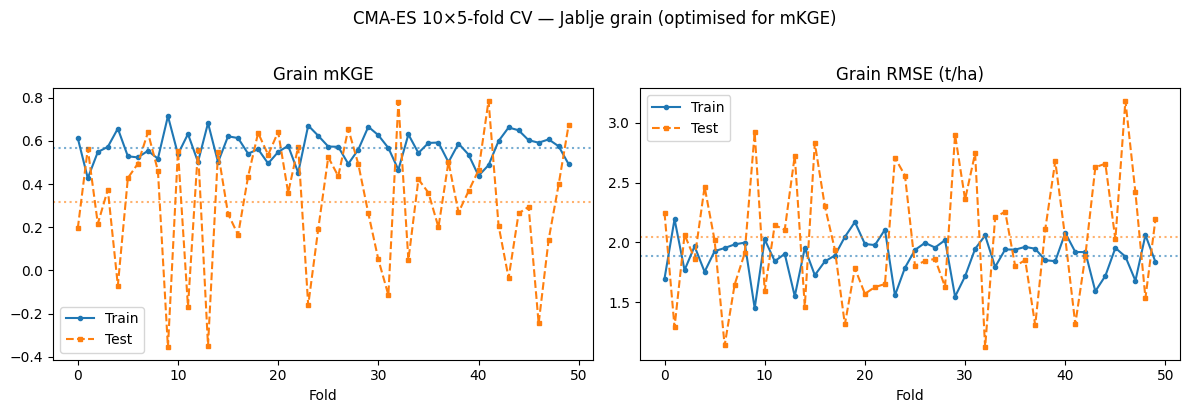

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], "grain_mkge", "Grain mKGE"),
    (axes[1], "grain_rmse", "Grain RMSE (t/ha)"),
]:
    ax.plot(results_df.index, results_df[f"train_{metric}"], "o-", label="Train", markersize=3)
    ax.plot(results_df.index, results_df[f"test_{metric}"],  "s--", label="Test", markersize=3)
    ax.axhline(results_df[f"train_{metric}"].mean(), color="C0", linestyle=":", alpha=0.6)
    ax.axhline(results_df[f"test_{metric}"].mean(),  color="C1", linestyle=":", alpha=0.6)
    ax.set_xlabel("Fold")
    ax.set_title(title)
    ax.legend()

fig.suptitle(f"CMA-ES {N_REPEATS}×{K_FOLDS}-fold CV — Jablje grain (optimised for mKGE)", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Re-run each fold's best params on its test years and collect predictions
all_predictions = []
for row in fold_results:
    xbest = [row[f"best_{n}"] for n in param_names]
    test_periods = make_simulation_periods(row["test_years"])

    crop_params = copy.deepcopy(jablje_maize_params)
    current_ksat = None
    for name, val in zip(param_names, xbest):
        if name == "ksat":
            current_ksat = float(val)
        else:
            crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    if current_ksat is not None:
        modified_layers = copy.deepcopy(jablje_soil_layers)
        for layer in modified_layers:
            layer.ksat = current_ksat
        current_soil = Soil(
            name=f"{LOCATION} soil",
            description="kfold-pred",
            soil_layers=modified_layers,
            curve_number=jablje_curve_number,
            readily_evaporable_water=jablje_readily_evaporable_water,
        )
    else:
        current_soil = soil

    pred_dir = config.RAMDISK_DIR / f"cmaes_jablje_kfold_pred_{row['fold']}"
    pred_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=test_periods,
        crop=Crop(name=f"{LOCATION} maize", description="kfold-pred", params=crop_params),
        soil=current_soil,
        management=jablje_optimal_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        working_dir=pred_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        seasonal = sim.run()["season"][["Year1", "Y(dry)"]].rename(
            columns={"Year1": "year", "Y(dry)": "grain_modeled"}
        )
    seasonal["fold"] = row["fold"]
    all_predictions.append(seasonal)

pred_df = pd.concat(all_predictions).merge(observed_grain, on="year")
print(f"Predictions assembled: {len(pred_df)} years")
pred_df

,year,grain_modeled,fold,yield
0,1993,7.698,1,7.830
1,1996,7.967,1,8.270
2,1997,10.987,1,10.369
3,1999,10.891,1,9.760
4,2009,10.084,1,5.129
...,...,...,...,...
295,2000,10.123,50,10.134
296,2004,10.416,50,6.108
297,2007,9.917,50,10.278
298,2020,11.596,50,13.514


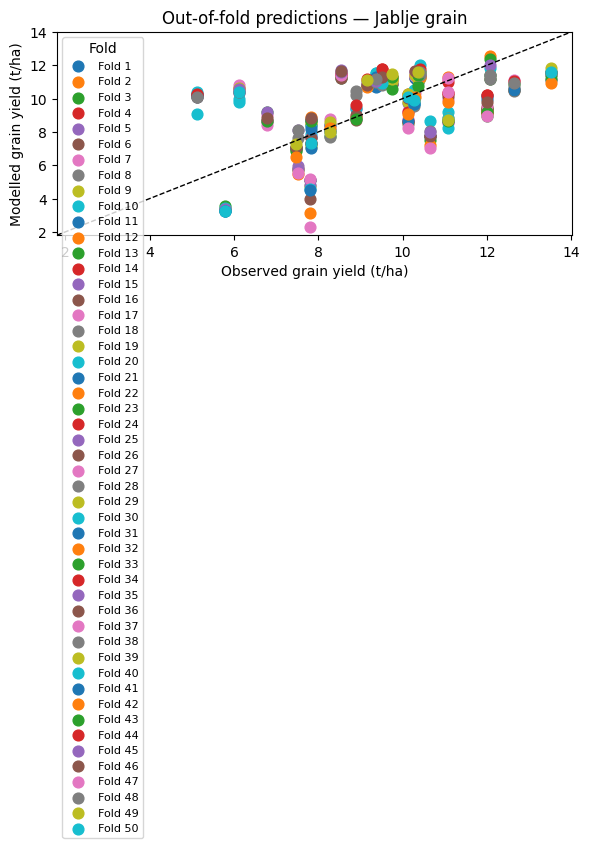

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

for fold_id, grp in pred_df.groupby("fold"):
    ax.scatter(grp["yield"], grp["grain_modeled"], label=f"Fold {fold_id}", s=60)

lim = [pred_df[["yield", "grain_modeled"]].min().min() - 0.5,
       pred_df[["yield", "grain_modeled"]].max().max() + 0.5]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Observed grain yield (t/ha)")
ax.set_ylabel("Modelled grain yield (t/ha)")
ax.set_title("Out-of-fold predictions — Jablje grain")
ax.legend(title="Fold", fontsize=8)
plt.tight_layout()
plt.show()

overall_mkge = mkge(pred_df["grain_modeled"].values, pred_df["yield"].values)
overall_rmse = root_mean_squared_error(pred_df["yield"].values, pred_df["grain_modeled"].values)
print(f"Overall out-of-fold mKGE: {overall_mkge:.4f}")
print(f"Overall out-of-fold RMSE: {overall_rmse:.4f} t/ha")